<a href="https://colab.research.google.com/github/sharemoonwithcoke/Chatting-Room/blob/main/Keras_CatsvsDogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Obtaining the dataset

The Dogs vs Cats dataset is available at https://www.kaggle.com/c/dogs-vs-cats/overview and consists of dogs and cats.

The full dataset constists 25,000 images. Here, we use a subset of the full dataset (containing only 2,000 images) to decrease training time.

We start with downloading the data, a .zip of 2,000 JPG pictures of cats and dogs, and extracting it locally in /tmp/DogsVsCats.


In [ ]:
!mkdir -p /tmp/DogsVsCats
!wget --no-check-certificate \
    https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip \
    -O /tmp/DogsVsCats/cats_and_dogs_filtered.zip

--2024-12-07 22:36:03--  https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.218.207, 142.251.31.207, 142.251.18.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.218.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘/tmp/DogsVsCats/cats_and_dogs_filtered.zip’

/tmp/DogsVsCats/cat 100%[===================>]  65.43M  29.7MB/s    in 2.2s    

2024-12-07 22:36:05 (29.7 MB/s) - ‘/tmp/DogsVsCats/cats_and_dogs_filtered.zip’ saved [68606236/68606236]



Extract the contents of the .zip to the base directory /tmp/DogsVsCats, which contains train and validation subdirectories for the training and validation datasets, which in turn each contain cats and dogs subdirectories.

In [ ]:
import os
import zipfile

local_zip = '/tmp/DogsVsCats/cats_and_dogs_filtered.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/DogsVsCats/')
zip_ref.close()

In [ ]:
!ls /tmp/DogsVsCats/cats_and_dogs_filtered/validation

cats  dogs


The train and validation directories contain the training and validation datasets, which in turn each contain cats and dogs subdirectories. We put all cat and dog images into the same directory.

In [ ]:
!cp -a /tmp/DogsVsCats/cats_and_dogs_filtered/train/cats/. /tmp/DogsVsCats/train/
!cp -a /tmp/DogsVsCats/cats_and_dogs_filtered/train/dogs/. /tmp/DogsVsCats/train/
!cp -a /tmp/DogsVsCats/cats_and_dogs_filtered/validation/cats/. /tmp/DogsVsCats/test/
!cp -a /tmp/DogsVsCats/cats_and_dogs_filtered/validation/dogs/. /tmp/DogsVsCats/test/

In [ ]:
train_data_dir = "/tmp/DogsVsCats/train/"
test_data_dir = "/tmp/DogsVsCats/test/"

train_imgs = os.listdir(train_data_dir)
test_imgs = os.listdir(test_data_dir)
print(len(train_imgs))
print(len(test_imgs))

2000
1000


In [ ]:
import numpy as np
import pandas as pd
import os
#from scipy import ndimage #This package contains various functions for multi-dimensional image processing.
import cv2
import scipy
import matplotlib.pyplot as plt
import sys

num_px = 64

def extrcatFeaturesAndLabels(dir, impg_dataset):
  X = np.zeros((len(impg_dataset), num_px*num_px*3))
  y = np.zeros((len(impg_dataset)))
  for i in range(0,len(impg_dataset)) :
    #Read an image from a file as an array.
    #The different colour bands/channels are stored
    #in the third dimension, such that a
    #grey-image is MxN, an RGB-image MxNx3
    #image = np.array(ndimage.imread(dir + impg_dataset[i]))
    image = cv2.imread(os.path.join(dir, impg_dataset[i]))


    # Resize the image. Size of the output image (height, width)
    image = cv2.resize(image, (num_px, num_px))

    # Convert the matrix to a vector
    image = image.reshape((1, num_px*num_px*3)).T

    # Note that RGB (Red, Green, Blue) are 8 bit each.
    # Hence, the range for each individual colour is 0-255 (as 2^8 = 256 possibilities).
    # By dividing by 255, Convert the 0-255 range to a 0.0-1.0 range where 0.0 means 0 (0x00) and 1.0 means 255 (0xFF).
    image = image/255.0

    image = image.reshape((num_px*num_px*3,1))
    for j in range(0,num_px*num_px*3):
        X[i][j] = image[j][0]

    if 'dog' in impg_dataset[i]:
        y[i] = 0
    else :
        y[i] = 1

  y = y.astype(int)

  return(X, y)

def get_acuuracy(model, X, y):
  y_pred = model.predict(X)

  if sys.version_info < (3, 0):
      accuracy = ((np.sum(y == y_pred, axis=0)).astype('float') /
            X.shape[0])
  else:
      accuracy = np.sum(y == y_pred, axis=0) / X.shape[0]

  #print('Accuracy: %.2f%%' % (accuracy * 100))

  return(accuracy * 100)

Training Data Set

Images can be represented as a matrix with number of elements equal to the number of pixels. However, color images are digitally represented as a volume (i.e., three-channels; or three matrices stacked on each other). The number three is used because colors are represented as red-green-blue (RGB) values. Here, we have a 64 × 64 × 3 image for each example and it is flattened into a single vector containing 12,288 elements.

In [ ]:
from scipy import ndimage
train_X, train_Y = extrcatFeaturesAndLabels(train_data_dir, train_imgs)

In [ ]:
test_X, test_Y = extrcatFeaturesAndLabels(test_data_dir, test_imgs)

In [ ]:
print('Training Data set - Rows: %d, columns: %d' % (train_X.shape[0], train_X.shape[1]))
print('Test Data set - Rows: %d, columns: %d' % (test_X.shape[0], test_X.shape[1]))

Training Data set - Rows: 2000, columns: 12288
Test Data set - Rows: 1000, columns: 12288


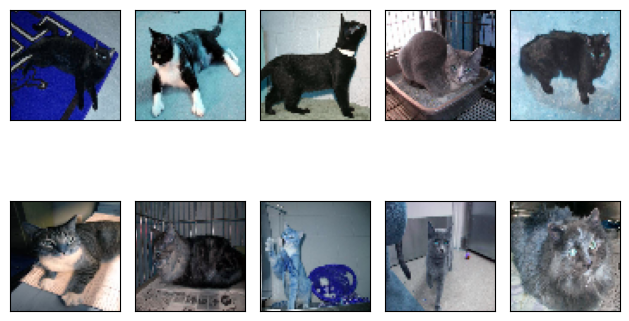

In [ ]:
#10 different images of Cat:
fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True,)
ax = ax.flatten()
for i in range(10):
    img = train_X[train_Y == 1][i].reshape(num_px, num_px, 3)
    ax[i].imshow(img)

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

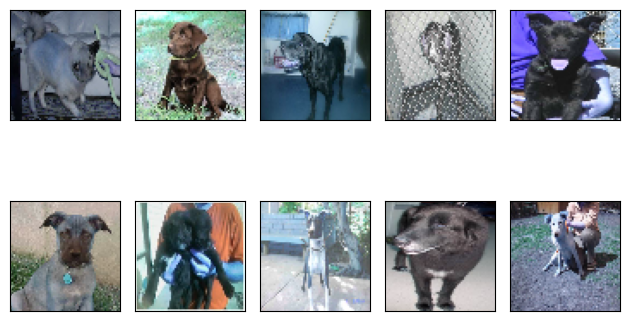

In [ ]:
#10 different images of Dog:
fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True,)
ax = ax.flatten()
for i in range(10):
    img = train_X[train_Y == 0][i].reshape(num_px, num_px, 3)
    ax[i].imshow(img)

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
print('Training data shape : ', train_X.shape, train_Y.shape) #print the shape of the training data using the train_X.shape, train_Y.shape functions.

print('Testing data shape : ', test_X.shape, test_Y.shape) #print the shape of the test data using the test_X.shape and test_Y.shape functions.

Training data shape :  (2000, 64, 64, 3) (2000,)
Testing data shape :  (1000, 64, 64, 3) (1000,)


In [ ]:
# Find the unique numbers from the train labels
classes = np.unique(train_Y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  2
Output classes :  [0 1]


In [ ]:
train_X = train_X.reshape(-1, 64,64, 3) # convert each 64 x 64 x 3  image of the train datta into a matrix of size 64 x 64 x 3  which is fed into the network.
test_X = test_X.reshape(-1, 64,64, 3) #  # convert each 64 x 64 x 3  image of the train datta into a matrix of size 64 x 64 x 3  which is fed into the network.

print('Training data shape : ', train_X.shape, train_Y.shape) #print the shape of the training data using the train_X.shape, train_Y.shape functions.
print('Testing data shape : ', test_X.shape, test_Y.shape) #print the shape of the test data using the test_X.shape and test_Y.shape functions.


Training data shape :  (2000, 64, 64, 3) (2000,)
Testing data shape :  (1000, 64, 64, 3) (1000,)


In [ ]:
# Change the labels from categorical to one-hot encoding
import keras
train_Y_one_hot = keras.utils.to_categorical(train_Y, 2)
test_Y_one_hot = keras.utils.to_categorical(test_Y, 2)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 1
After conversion to one-hot: [0. 1.]


In [ ]:
import keras
from keras.models import Sequential#,Input,Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D


In [ ]:
model = Sequential()#create a convolutional neural network (CNN) model for image classification.
model.add(Conv2D(32, kernel_size=(3, 3),activation='relu',input_shape=(64,64,3),padding='same')) #apply 32 filters of size 3*3.  The padding parameter is set to 'same', which means that the output size of the layer will be the same as the input size.
model.add(MaxPooling2D((2, 2),padding='same'))
model.add(Conv2D(64, (3, 3), activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2),padding='same'))
model.add(Conv2D(128, (3, 3), activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2),padding='same'))
model.add(Dropout(0.5, input_shape=(2,)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(2, activation='softmax')) #num_classes = 2



In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,142,210 (4.36 MB)

 Trainable params: 1,142,210 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compile the specified model
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(),metrics=['accuracy'])
#model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])



In [ ]:
#Fit the model using the training data
batch_size = 1
epochs = 10
model.fit(train_X, train_Y_one_hot, batch_size=batch_size, epochs=epochs,verbose=1) # The verbose argument is set to 1, which means that the evaluation progress and results will be displayed on the console.

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 250ms/step - accuracy: 0.5025 - loss: 0.7179
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 237ms/step - accuracy: 0.5365 - loss: 0.6886
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 230ms/step - accuracy: 0.6540 - loss: 0.6378
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 225ms/step - accuracy: 0.6665 - loss: 0.6235
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.6962 - loss: 0.5909
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 228ms/step - accuracy: 0.7037 - loss: 0.5760
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 233ms/step - accuracy: 0.7470 - loss: 0.5223
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 231ms/step - accuracy: 0.7639 - loss: 0.4898
Epoch 9/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 254ms/step - accuracy: 0.7965 - loss: 0.4349
Epoch 10/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.7991 - loss: 0.4211


In [ ]:
#Fit the model using the training data
batch_size = 10
epochs = 20
model.fit(train_X, train_Y_one_hot, batch_size=batch_size, epochs=epochs,verbose=1) # The verbose argument is set to 1, which means that the evaluation progress and results will be displayed on the console.

Epoch 1/20
200/200 [==============================] - 20s 93ms/step - loss: 0.6957 - accuracy: 0.5030
Epoch 2/20
200/200 [==============================] - 18s 90ms/step - loss: 0.6720 - accuracy: 0.5885
Epoch 3/20
200/200 [==============================] - 17s 87ms/step - loss: 0.6375 - accuracy: 0.6510
Epoch 4/20
200/200 [==============================] - 19s 93ms/step - loss: 0.6035 - accuracy: 0.6905
Epoch 5/20
200/200 [==============================] - 18s 88ms/step - loss: 0.5693 - accuracy: 0.7075
Epoch 6/20
200/200 [==============================] - 18s 91ms/step - loss: 0.5299 - accuracy: 0.7365
Epoch 7/20
200/200 [==============================] - 18s 88ms/step - loss: 0.4886 - accuracy: 0.7550
Epoch 8/20
200/200 [==============================] - 17s 87ms/step - loss: 0.4676 - accuracy: 0.7690
Epoch 9/20
200/200 [==============================] - 18s 92ms/step - loss: 0.4160 - accuracy: 0.8175
Epoch 10/20
200/200 [==============================] - 17s 87ms/step - loss: 0.380

In [ ]:
model.evaluate(test_X, test_Y_one_hot, verbose=1)

32/32 [==============================] - 2s 67ms/step - loss: 0.7914 - accuracy: 0.7500


[0.7913580536842346, 0.75]

In [ ]:
predicted_classes = model.predict(test_X)